# Recurrent Neural Networks

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
import numpy as np
import pandas as pd
import os.path
import subprocess
import matplotlib.collections
import scipy.signal
from sklearn import model_selection
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Use CPU rather than GPU for keras neural networks
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = ""
from tensorflow import keras
from tqdm.keras import TqdmCallback

2026-02-24 00:11:25.968202: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-24 00:11:25.995645: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-24 00:11:26.535934: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## <span style="color:Orange">Recurrent Networks</span>

All the architectures we have seen so far are **feed-foward** networks, with input data always from left (input layer) to right (output layer). A <span style="color:Violet">recurrent neural network</span> (RNN) adds links that feed back into a previous layer. This simple modification adds significant complexity but also expressive power (comparable to the electronics revolution associated with the idea of transistor feedback).

Architectures with feedback are still maturing but some useful building blocks have emerged, such as the [long short-term memory unit](https://en.wikipedia.org/wiki/Long_short-term_memory), which allows a network to remember some internal state but also forget it based on new input.

Some practical considerations for RNN designs:
 - The order of training data is now significant and defines a "model time", but the network can be reset whenever needed.

 - Input data can be packaged into variable-length messages that generate variable (and different) length output messages. This is exactly what language translation needs.

 - Optimization of the weights using gradients is still possible but requires "unrolling" the network by cloning it enough times to process the longest allowed messages.

A feed-foward network implements a universal approximating function. Since the internal state of an RNN acts like local variables, you can think of an RNN as a universal approximating program.

See this [blog post](http://karpathy.github.io/2015/05/21/rnn-effectiveness/) for an example based on natural language synthesis.

A "recurrent" neural network is not exactly feedforward.
There are a variety of forms for a recurrent network, but using the previous diagramming method, we can write the most common form as:

<img src="https://raw.githubusercontent.com/GDS-Education-Community-of-Practice/DSECOP/main/Time_Series_Analysis_and_Forecasting/diagrams/recurrent_nn_loop.drawio.svg" width=300 align=center></img><br>

As you can see, there is a loop (the recurrent part) which passes information from one evaluation of the function to the next time the function is evaluated.
This might seem strange at first glance but makes more sense when you consider a sequence of events.
For example, words.
If we have three words of a sentence, predicting the next word likely depends on all three words rather than only the previous.

### <span style="color:LightGreen">Stucture</span>

The "looped" diagram shown above can also be written in an "unrolled" form as follows:

___<span style="color:Tan">Many-to-many</span>___

<img src="https://raw.githubusercontent.com/GDS-Education-Community-of-Practice/DSECOP/main/Time_Series_Analysis_and_Forecasting/diagrams/recurrent_nn1.drawio.svg" width=600 align=center></img><br>

Note that this form of recurrent neural network requires inputs at each step and gives outputs at each step.
This is is not strictly necessary and you could instead have only the end output or only one input and one output as show below:

___<span style="color:Tan">Many-to-one</span>___

<img src="https://raw.githubusercontent.com/GDS-Education-Community-of-Practice/DSECOP/main/Time_Series_Analysis_and_Forecasting/diagrams/recurrent_nn2.drawio.svg" width=600 align=center></img><br>

___<span style="color:Tan">One-to-one</span>___

<img src="https://raw.githubusercontent.com/GDS-Education-Community-of-Practice/DSECOP/main/Time_Series_Analysis_and_Forecasting/diagrams/recurrent_nn3.drawio.svg" width=600 align=center></img><br>

Each of the demonstrated diagrams features a very simple version of the neural network, but it could have many layers at each step such as the following:

<img src="https://raw.githubusercontent.com/GDS-Education-Community-of-Practice/DSECOP/main/Time_Series_Analysis_and_Forecasting/diagrams/recurrent_nn_loop2.drawio.svg" width=300 align=center></img><br>

Fortunately, these can all be easily implemented using the `keras` framework.
Let's return to our example of input data of the form $[\sin(t),\cos(t)]$ and outputs of the form $\sin(t)\cos(t)$ but lets try to use 2 values of $t$ to get the next value.
So, we will pass in something like

$$ \Large
\begin{bmatrix}
\sin(t_1) & \cos(t_1) \\
\sin(t_2) & \cos(t_2)
\end{bmatrix}
$$

to get the output $\sin(t_3)\cos(t_3)$.
We'll use two layers.
See below for examples of these recurrent neural network forms:

In [3]:
keras.utils.set_random_seed(0)

# Make input layer of appropriate size (2 samples of size 2 or 1 sample of size 2)
x_many   = keras.layers.Input(shape=(2,2))
x_one    = keras.layers.Input(shape=(1,2))

# Pass input x into first layer of size 3 x 2
# return_sequences=True means there is an output for each input
y_many = keras.layers.SimpleRNN(3,activation="tanh", return_sequences=True)(x_many)
y_one  = keras.layers.SimpleRNN(3,activation="tanh", return_sequences=True)(x_one)
y_many_to_many = keras.layers.SimpleRNN(1,activation="tanh", return_sequences=True)(y_many)
y_many_to_one  = keras.layers.SimpleRNN(1,activation="tanh", return_sequences=False)(y_many)
y_one_to_one   = keras.layers.SimpleRNN(1,activation="tanh", return_sequences=False)(y_one)

many_to_many = keras.Model(inputs=x_many,outputs=y_many_to_many)
many_to_one  = keras.Model(inputs=x_many,outputs=y_many_to_one)
one_to_one   = keras.Model(inputs=x_one ,outputs=y_one_to_one)

2026-02-24 00:11:26.647217: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-02-24 00:11:26.647242: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES=""
2026-02-24 00:11:26.647247: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to an empty string - this hides all GPUs from CUDA
2026-02-24 00:11:26.647249: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2026-02-24 00:11:26.647252: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: sob
2026-02-24 00:11:26.647254: I external/local_xla/xla/stream_executor/cud

In [4]:
# 1 batch of 2 random samples of size 2
sample_many = np.random.random(size=(1,2,2))
sample_one  = np.random.random(size=(1,1,2))

print("Sample of 2: \n{}".format(sample_many))
print("Many to many output: \n{}".format(many_to_many(sample_many)))
print("Many to one output: \n{}".format(many_to_one(sample_many)))
print("Sample of 1: \n{}".format(sample_one))
print("One to one output: \n{}".format(one_to_one(sample_one)))

Sample of 2: 
[[[0.5488135  0.71518937]
  [0.60276338 0.54488318]]]
Many to many output: 
[[[-0.5552849 ]
  [ 0.16151643]]]
Many to one output: 
[[0.26074675]]
Sample of 1: 
[[[0.4236548  0.64589411]]]
One to one output: 
[[-0.40512714]]


The number passed into the `SimpleRNN` is the number of loops performed.
In the case described above, we want to take samples at times $t_1$ and $t_2$ and output the value of the function at time $t_3$.
This is a "many-to-one" case.

In order to train the network to perform well in this case, we need to arrange our data in pairs of

$$ \Large
\begin{bmatrix}
\sin(t_i) & \cos(t_{i}) \\
\sin(t_{i+1}) & \cos(t_{i+1})
\end{bmatrix}
$$

aligned with outputs $\sin(t_{i+2})\cos(t_{i+2})$:

In [5]:
# Make our data samples
t_values = np.linspace(0,10,100)
samples = np.vstack([np.sin(t_values), np.cos(t_values)]).T
output_values = np.sin(t_values)*np.cos(t_values)

# Arrange our data samples
input_samples = []
output_samples = []
for i in range(98):
  # Take two samples at time t_i and t_{i+1}
  input_samples.append(samples[i:i+2])
  # Get function output at time t_{i+2}
  output_samples.append(output_values[i+2])

input_samples = np.array(input_samples)
output_samples = np.array(output_samples)

We can now compile the many to one model and train it on this test data.

0epoch [00:00, ?epoch/s]

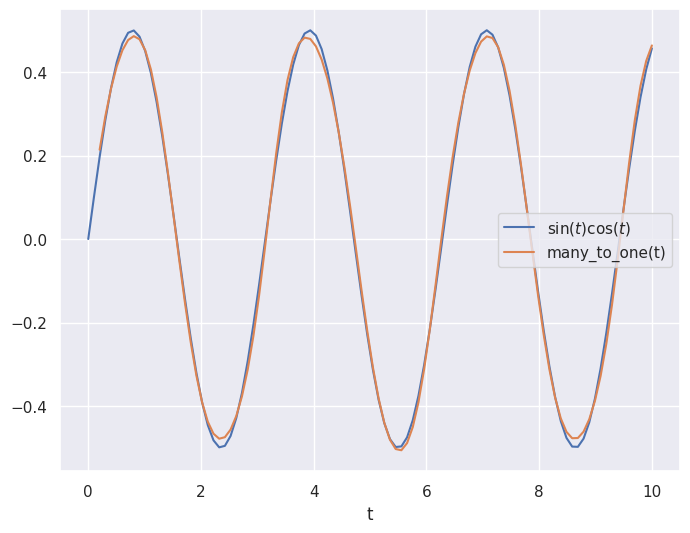

In [6]:
# Train model
many_to_one.compile(
    optimizer = keras.optimizers.Adam(),
    loss = keras.losses.MeanSquaredError()
)
history = many_to_one.fit(
    input_samples,
    output_samples,
    batch_size=10,         # The training takes groups of samples (in this case 10 samples at a time)
    epochs=500,            # The number of times to iterate through our dataset
    validation_split = 0.2,# Use 20% of data to check accuracy
    verbose=0,             # Don't print info as it trains
    callbacks=[TqdmCallback(verbose=0)]
)

# Plot prediction and the true values
plt.close('all')
plt.figure(figsize=(8,6))
plt.plot(t_values, output_values, label="$\sin(t)\cos(t)$")
plt.plot(t_values[2:], many_to_one(input_samples), label="many_to_one(t)")
plt.legend()
plt.xlabel("t")
plt.show()

Similar to the feedforward neural network, the recurrent architecture was able to roughly approximate the curve!

Although it is not very noticeable in this case, the recurrent model can also uses less weights and biases (because it has the looping behavior built in) making it less computationally expensive and easier to train! This has made the recurrent architecture very popular for time series like applications for real world problems (in fact, modern transformers such as ChatGPT are built on the same concepts as RNNs).

## <span style="color:Orange">Acknowledgments</span>

* Initial version: Mark Neubauer

© Copyright 2026